# Prime density and divergent sums

This notebook studies the global distribution of primes, inspired by Don Zagier's *The First 50 Million Prime Numbers*. We generate primes with a sieve, compare exactly two approximations to the prime-counting function, and investigate several forms of Euler's theorem that the reciprocal-prime sum diverges.

The companion notebook `primes_in_arithmetic_progressions.ipynb` studies residue classes.

In [31]:
from math import isqrt, log
from pathlib import Path
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid": True, "figure.dpi": 110})

# Laptop-friendly default. Try 50_000_000 for a larger run.
N = 10_000_000

## 1. Generate the primes

The odd-only sieve stores one Boolean per odd integer. When a prime $p$ survives, it crosses out $p^2,p^2+2p,p^2+4p,\ldots$.

In [32]:
def odd_sieve(n):
    """Return all primes p with 2 <= p <= n."""
    if not isinstance(n, (int, np.integer)):
        raise TypeError("n must be an integer")
    if n < 2:
        return np.array([], dtype=np.int64)
    odd = np.ones((n + 1)//2, dtype=bool)
    odd[0] = False
    for p in range(3, isqrt(n)+1, 2):
        if odd[p//2]:
            odd[p*p//2::p] = False
    return np.concatenate(([2], 2*np.flatnonzero(odd)+1)).astype(np.int64)

t0 = perf_counter()
primes = odd_sieve(N)
print(f"Generated {len(primes):,} primes through {N:,} in {perf_counter()-t0:.2f} s.")
print("Last ten primes:", primes[-10:])
assert len(odd_sieve(100)) == 25
if N >= 1_000_000:
    assert np.searchsorted(primes, 1_000_000, side="right") == 78_498

Generated 664,579 primes through 10,000,000 in 0.03 s.
Last ten primes: [9999889 9999901 9999907 9999929 9999931 9999937 9999943 9999971 9999973
 9999991]


### Optional full Zagier range

Zagier's title means the first 50 million primes, reaching approximately $10^9$. The course folder contains this dataset. Change `False` to `True` to use it below.

In [ ]:
if False:
    candidates = [Path("primes_up_to_1000000000.npy"),
                  Path("Shared_with_students/notebooks/primes/primes_up_to_1000000000.npy")]
    data_path = next((p for p in candidates if p.exists()), None)
    if data_path is None:
        raise FileNotFoundError("Could not locate the supplied prime dataset")
    primes = np.load(data_path, mmap_mode="r")
    N = int(primes[-1])
    print(f"Loaded {len(primes):,} primes; largest is {N:,}.")

## 2. Two approximations to $\pi(x)$

We compare only

$$\frac{x}{\log x} \qquad\text{and}\qquad \operatorname{Li}(x)=\int_2^x\frac{dt}{\log t}.$$

The prime number theorem says $\pi(x)/(x/\log x)\to1$. The logarithmic integral accounts for the changing local density $1/\log t$ and is much more accurate in this range.

In [33]:
EULER_GAMMA = 0.5772156649015329

def li_standard(x, terms=120):
    """Conventional li(x)=Ei(log x), evaluated by a convergent series."""
    values = np.asarray(x, dtype=float)
    if np.any(values <= 1):
        raise ValueError("x must be greater than 1")
    y = np.log(values)
    total = EULER_GAMMA + np.log(y)
    term = np.ones_like(y)
    for k in range(1, terms+1):
        term *= y/k
        total += term/k
    return total

def Li(x):
    return li_standard(x) - li_standard(2)

max_power = int(np.floor(np.log10(N)))
sample_x = np.unique(np.concatenate((np.logspace(1, np.log10(N), 350).astype(np.int64),
                                      10**np.arange(1, max_power+1, dtype=np.int64))))
pi_x = np.searchsorted(primes, sample_x, side="right")
pnt_x = sample_x/np.log(sample_x)
li_x = Li(sample_x)

             x        pi(x)    x/log x error    Li(x) error
           100           25             -3.3            4.1
         1,000          168            -23.2            8.6
        10,000        1,229           -143.3           16.1
       100,000        9,592           -906.1           36.8
     1,000,000       78,498          -6115.6          128.5
    10,000,000      664,579         -44158.3          338.4


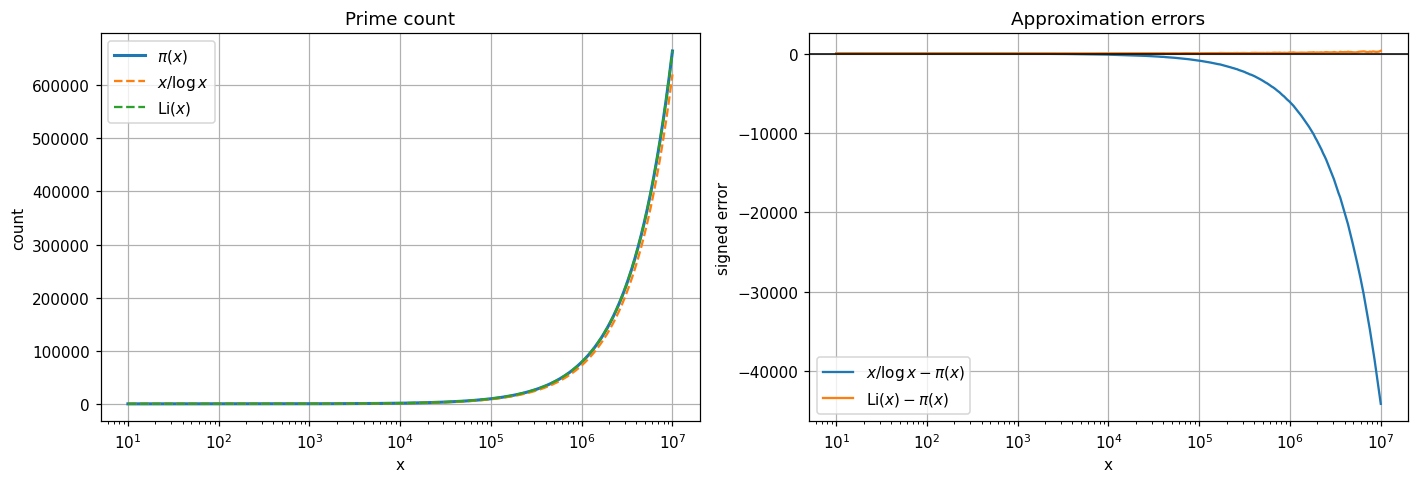

In [34]:
print(f"{'x':>14} {'pi(x)':>12} {'x/log x error':>16} {'Li(x) error':>14}")
for x in 10**np.arange(2, max_power+1, dtype=np.int64):
    pix = np.searchsorted(primes, x, side="right")
    print(f"{x:14,d} {pix:12,d} {x/log(x)-pix:16.1f} {float(Li(x))-pix:14.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(sample_x, pi_x, label=r"$\pi(x)$", linewidth=2)
axes[0].plot(sample_x, pnt_x, "--", label=r"$x/\log x$")
axes[0].plot(sample_x, li_x, "--", label=r"$\operatorname{Li}(x)$")
axes[0].set(xscale="log", xlabel="x", ylabel="count", title="Prime count"); axes[0].legend()
axes[1].plot(sample_x, pnt_x-pi_x, label=r"$x/\log x-\pi(x)$")
axes[1].plot(sample_x, li_x-pi_x, label=r"$\operatorname{Li}(x)-\pi(x)$")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(xscale="log", xlabel="x", ylabel="signed error", title="Approximation errors"); axes[1].legend()
plt.tight_layout(); plt.show()

## 3. The divergent reciprocal-prime sum

Euler proved $\sum_p 1/p=\infty$. More precisely,

$$\sum_{p\leq x}\frac1p=\log\log x+B_1+o(1),$$

where $B_1\approx0.2614972128$ is the Meissel--Mertens constant. The double logarithm makes this divergence exceptionally slow.

             x        sum 1/p     log log x+B1    difference
            10    1.176190476      1.095529658     8.066e-02
           100    1.802817201      1.788676839     1.414e-02
         1,000    2.198080127      2.194141947     3.938e-03
        10,000    2.483059947      2.481824019     1.236e-03
       100,000    2.705272179      2.704967570     3.046e-04
     1,000,000    2.887328100      2.887289127     3.897e-05
    10,000,000    3.041449381      3.041439807     9.574e-06


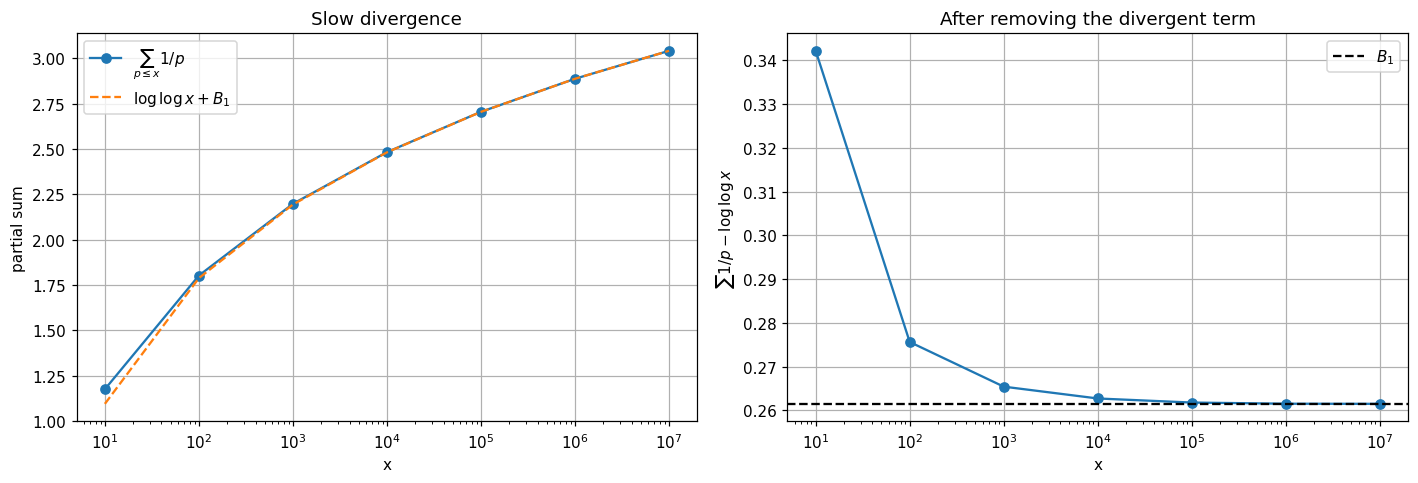

In [35]:
B1 = 0.2614972128
reciprocal_sums = np.cumsum(1.0/primes)
power_x = 10**np.arange(1, max_power+1, dtype=np.int64)
ends = np.searchsorted(primes, power_x, side="right")
S = reciprocal_sums[ends-1]
print(f"{'x':>14} {'sum 1/p':>14} {'log log x+B1':>16} {'difference':>13}")
for x, s in zip(power_x, S):
    model = log(log(x))+B1
    print(f"{x:14,d} {s:14.9f} {model:16.9f} {s-model:13.3e}")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(power_x, S, "o-", label=r"$\sum_{p\leq x}1/p$")
axes[0].plot(power_x, np.log(np.log(power_x))+B1, "--", label=r"$\log\log x+B_1$")
axes[0].set(xscale="log", xlabel="x", ylabel="partial sum", title="Slow divergence"); axes[0].legend()
axes[1].plot(power_x, S-np.log(np.log(power_x)), "o-")
axes[1].axhline(B1, color="black", linestyle="--", label=r"$B_1$")
axes[1].set(xscale="log", xlabel="x", ylabel=r"$\sum 1/p-\log\log x$", title="After removing the divergent term"); axes[1].legend()
plt.tight_layout(); plt.show()

### Contributions from successive decades

The primes in $[10^k,10^{k+1}]$ contribute approximately $\log((k+1)/k)$. Each new decade contributes less, although the total never stops growing.

            decade     observed   prediction
[10^0, 10^1]:    1.1761905          nan
[10^1, 10^2]:    0.6266267    0.6931472
[10^2, 10^3]:    0.3952629    0.4054651
[10^3, 10^4]:    0.2849798    0.2876821
[10^4, 10^5]:    0.2222122    0.2231436
[10^5, 10^6]:    0.1820559    0.1823216
[10^6, 10^7]:    0.1541213    0.1541507


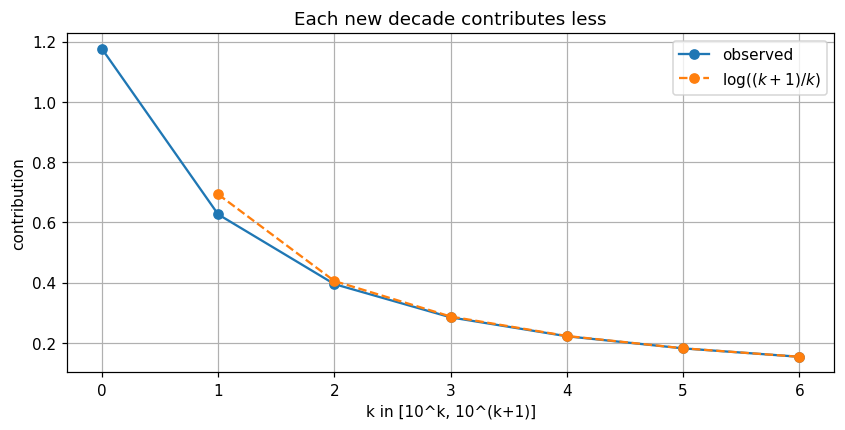

In [36]:
contributions = np.diff(np.r_[0.0, S])
prediction = np.array([np.nan]+[log((k+1)/k) for k in range(1, len(S))])
print(f"{'decade':>18} {'observed':>12} {'prediction':>12}")
for k, observed in enumerate(contributions):
    predicted = prediction[k]
    print(f"[10^{k}, 10^{k+1}]: {observed:12.7f} {predicted:12.7f}")
plt.figure(figsize=(9, 4))
plt.plot(range(len(S)), contributions, "o-", label="observed")
plt.plot(range(1, len(S)), prediction[1:], "o--", label=r"$\log((k+1)/k)$")
plt.xlabel("k in [10^k, 10^(k+1)]"); plt.ylabel("contribution")
plt.title("Each new decade contributes less"); plt.legend(); plt.show()

### How slow is $\log\log x$?

To increase the sum by about $d$, the model requires $X\approx x^{e^d}$. We report the order of magnitude of $X$ rather than constructing it.

In [37]:
print(f"At x={N:,}, the sum is only {reciprocal_sums[-1]:.6f}.")
for increase in [0.5, 1, 2, 5]:
    log10_X = np.exp(increase)*np.log10(N)
    print(f"An increase of about {increase:g} requires X of order 10^{log10_X:.1f}.")

At x=10,000,000, the sum is only 3.041449.
An increase of about 0.5 requires X of order 10^11.5.
An increase of about 1 requires X of order 10^19.0.
An increase of about 2 requires X of order 10^51.7.
An increase of about 5 requires X of order 10^1038.9.


### The Euler product form

The same divergence appears in Mertens' product theorem:

$$\prod_{p\leq x}\left(1-\frac1p\right)^{-1}\sim e^\gamma\log x.$$

We calculate logarithms first for numerical stability.

             x    Euler product    e^gamma log x      ratio
            10       4.37500000       4.10107080   1.066795
           100       8.31135738       8.20214160   1.013316
         1,000      12.35097567      12.30321240   1.003882
        10,000      16.42448963      16.40428320   1.001232
       100,000      20.51159283      20.50535400   1.000304
     1,000,000      24.60738295      24.60642480   1.000039
    10,000,000      28.70777036      28.70749559   1.000010


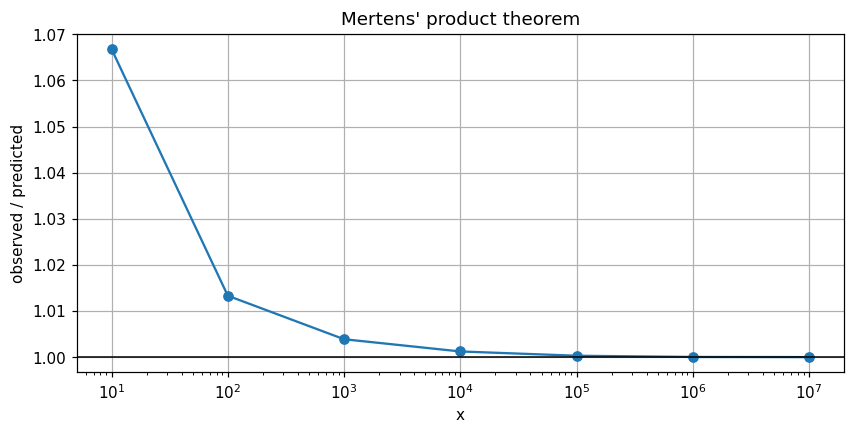

In [38]:
log_products = np.cumsum(-np.log1p(-1.0/primes))
products = np.exp(log_products[ends-1])
model_products = np.exp(EULER_GAMMA)*np.log(power_x)
print(f"{'x':>14} {'Euler product':>16} {'e^gamma log x':>16} {'ratio':>10}")
for x, product, model in zip(power_x, products, model_products):
    print(f"{x:14,d} {product:16.8f} {model:16.8f} {product/model:10.6f}")
plt.figure(figsize=(9, 4)); plt.plot(power_x, products/model_products, "o-")
plt.axhline(1, color="black", linewidth=1); plt.xscale("log")
plt.xlabel("x"); plt.ylabel("observed / predicted"); plt.title("Mertens' product theorem"); plt.show()

### The boundary between convergence and divergence

For every $\alpha>1$, $\sum_p p^{-\alpha}$ converges, while $\alpha=1$ diverges. Finite partial sums show how hard it is to distinguish slow divergence from slow convergence experimentally.

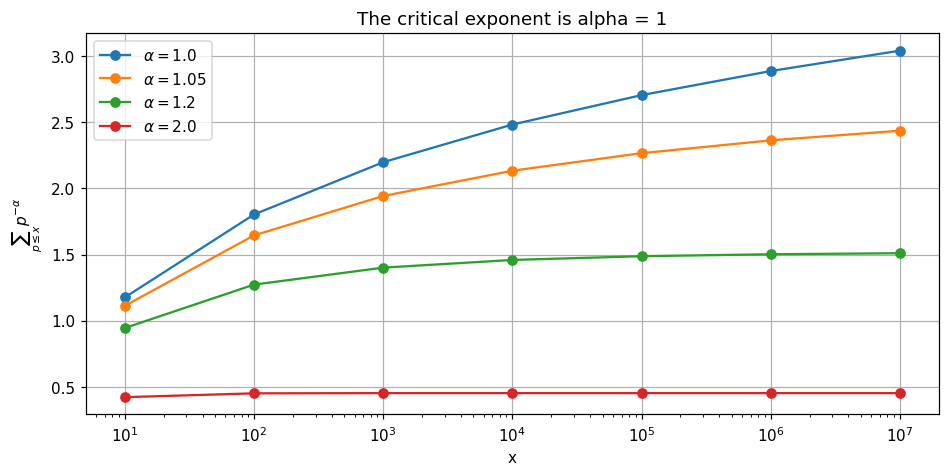

In [39]:
alphas = [1.0, 1.05, 1.2, 2.0]
plt.figure(figsize=(10, 4.5))
for alpha in alphas:
    cumulative = np.cumsum(primes.astype(float)**(-alpha))
    plt.plot(power_x, cumulative[ends-1], "o-", label=fr"$\alpha={alpha}$")
plt.xscale("log"); plt.xlabel("x"); plt.ylabel(r"$\sum_{p\leq x}p^{-\alpha}$")
plt.title("The critical exponent is alpha = 1"); plt.legend(); plt.show()

## Further experiments

1. Compare $\sum_{p\leq x}1/p$ with the harmonic sum $\sum_{n\leq x}1/n\sim\log x$.
2. Estimate when the reciprocal-prime sum exceeds $4$, $5$, or $10$.
3. Fit $B_1$ using only the computed data and track the estimate as $x$ grows.
4. Replace decades by intervals $[x,2x]$ and measure their contributions.
5. Study mean prime gaps near $x$ and compare them with $\log x$.

## Reference

Don Zagier, *The First 50 Million Prime Numbers*, **The Mathematical Intelligencer** (1977). The course copy is `Shared_with_students/documentos/zagier_on_primes.pdf`.